In [1]:
import udkm1Dsim as ud
u = ud.u  # import the pint unit registry from udkm1Dsim
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
u.setup_matplotlib()  # use matplotlib with pint units

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
Fe = ud.Atom('Fe', mag_amplitude=1.0, mag_phi=90*u.deg, mag_gamma=90*u.deg,
                   atomic_form_factor_path='./fe.nff', magnetic_form_factor_path='./fe.mf')
Si = ud.Atom('Si', atomic_form_factor_source='henke')

In [4]:
density_Fe = 7874*u.kg/u.m**3

prop_Fe = {}
prop_Fe['heat_capacity'] = 449*u.J/u.kg/u.K
prop_Fe['therm_cond'] = 80*u.W/(u.m *u.K)
prop_Fe['lin_therm_exp'] = 11.8e-6
prop_Fe['sound_vel'] = 4.910*u.nm/u.ps
prop_Fe['opt_ref_index'] = 2.9174+3.3545j

layer_Fe = ud.AmorphousLayer('Fe', 'Fe amorphous', 1*u.nm,
                                  density_Fe, atom=Fe, **prop_Fe)

In [5]:
density_Si = 2336*u.kg/u.m**3

prop_Si = {}
prop_Si['heat_capacity'] = 703*u.J/u.kg/u.K
prop_Si['therm_cond'] = 150*u.W/(u.m*u.K)
prop_Si['lin_therm_exp'] = 2.6e-6
prop_Si['sound_vel'] = 8.433*u.nm/u.ps
prop_Si['opt_ref_index'] = 3.6941+0.0065435j

layer_Si = ud.AmorphousLayer('Si', "Si amorphous", 100*u.nm, density_Si, atom=Si, **prop_Si)

In [6]:
S = ud.Structure('Fe on Si')

S.add_sub_structure(layer_Fe, 10)
S.add_sub_structure(layer_Si, 200)

In [7]:
dyn_mag = ud.XrayDynMag(S, True)
dyn_mag.disp_messages = True
dyn_mag.save_data = False

incoming polarizations set to: sigma
analyzer polarizations set to: unpolarized


In [8]:
dyn_mag.theta = np.r_[5:55:1]*u.deg
dyn_mag.energy = np.r_[46:70:1]*u.eV  # set two photon energies


# T-MOKE

180 deg
90 deg
incoming polarizations set to: pi
analyzer polarizations set to: unpolarized
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.416671 s


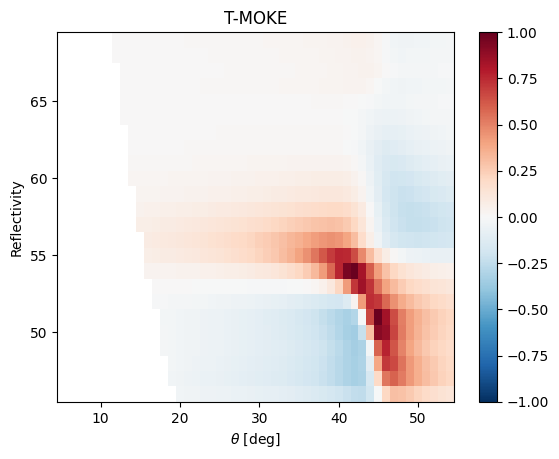

In [45]:
Fe.mag_gamma = 180*u.deg # s-pol
Fe.mag_phi = 90*u.deg # in-
print(dyn_mag.S.get_layer_handle(0).atom.mag_gamma)
print(dyn_mag.S.get_layer_handle(0).atom.mag_phi)

dyn_mag.set_polarization(4, 0)
R, R_phi, _, _ = dyn_mag.homogeneous_reflectivity()
asym = (R-R_phi)/((R+R_phi))

plt.figure()
plt.pcolormesh(dyn_mag.theta, dyn_mag.energy,
               (R-R_phi)/((R+R_phi)),
               shading='auto', vmin=-1, vmax=1, cmap='RdBu_r')
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel('Reflectivity')
plt.colorbar()
plt.title('T-MOKE')
plt.show()

incoming polarizations set to: pi
analyzer polarizations set to: unpolarized
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.423577 s


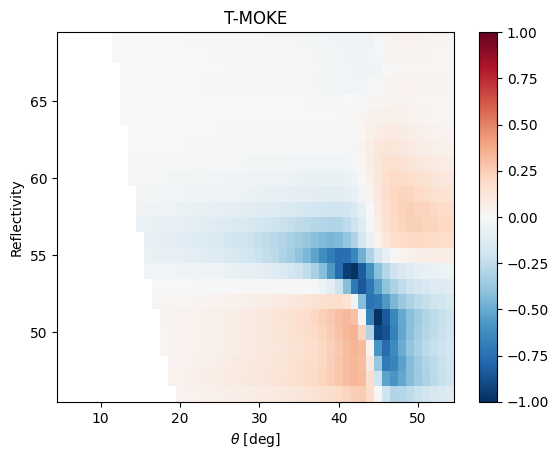

In [46]:
Fe.mag_gamma = 0*u.deg # s-pol
Fe.mag_phi = 90*u.deg # in-plane

dyn_mag.set_polarization(4, 0)
R, R_phi, _, _ = dyn_mag.homogeneous_reflectivity()
asym = (R-R_phi)/((R+R_phi))

plt.figure()
plt.pcolormesh(dyn_mag.theta, dyn_mag.energy,
               asym,
               shading='auto', vmin=-1, vmax=1, cmap='RdBu_r')
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel('Reflectivity')
plt.colorbar()
plt.title('T-MOKE')
plt.show()

# P-MOKE

incoming polarizations set to: sigma
analyzer polarizations set to: unpolarized
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.408392 s


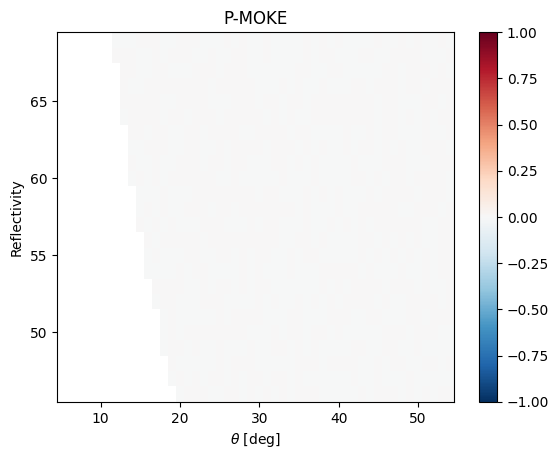

In [47]:
Fe.mag_gamma = 0*u.deg # s-pol
Fe.mag_phi = 0*u.deg # out-of-plane

dyn_mag.set_polarization(3, 0)
R, R_phi, _, _ = dyn_mag.homogeneous_reflectivity()
asym = (R-R_phi)/((R+R_phi))

plt.figure()
plt.pcolormesh(dyn_mag.theta, dyn_mag.energy,
               asym,
               shading='auto', vmin=-1, vmax=1, cmap='RdBu_r')
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel('Reflectivity')
plt.colorbar()
plt.title('P-MOKE')
plt.show()

incoming polarizations set to: elliptical
analyzer polarizations set to: unpolarized
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.448551 s


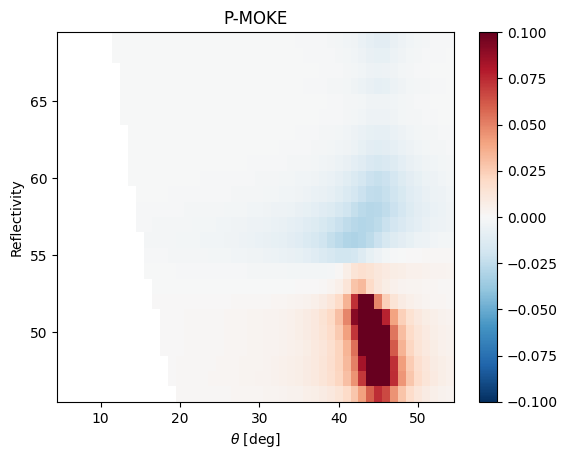

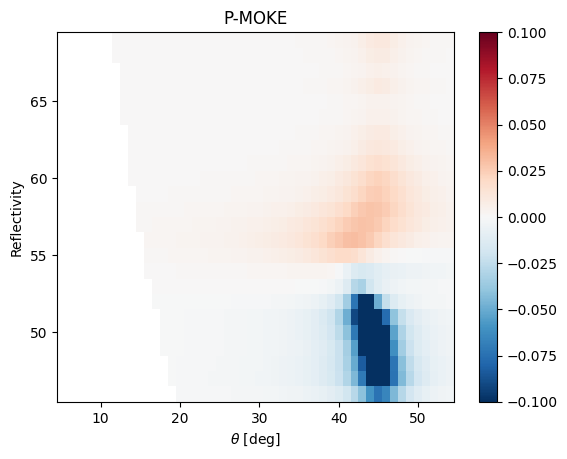

In [48]:
Fe.mag_gamma = 0*u.deg # s-pol
Fe.mag_phi = 0*u.deg # out-of-plane

# need to set the incoming polarization with angle and ellipticity
dyn_mag.set_incoming_polarization(5, [(89*u.deg, 0), (91*u.deg, 0)])
dyn_mag.set_outgoing_polarization(0)
R, R_phi, _, _ = dyn_mag.homogeneous_reflectivity()
asym = (R-R_phi)/((R+R_phi))

plt.figure()
plt.pcolormesh(dyn_mag.theta, dyn_mag.energy,
               asym[:, :, 0],
               shading='auto', vmin=-.1, vmax=.1, cmap='RdBu_r')
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel('Reflectivity')
plt.colorbar()
plt.title('P-MOKE')
plt.show()


plt.figure()
plt.pcolormesh(dyn_mag.theta, dyn_mag.energy,
               asym[:, :, 1],
               shading='auto', vmin=-.1, vmax=.1, cmap='RdBu_r')
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel('Reflectivity')
plt.colorbar()
plt.title('P-MOKE')
plt.show()

In [49]:


dyn_mag.energy = np.r_[46:65:1]*u.eV  # set two photon energies
dyn_mag.theta = np.r_[35:55:1]*u.deg

alphas = np.r_[70:110:1]*u.deg
polarizations_in = [(x, 0) for x in alphas]

magnetizations = np.r_[0:1.1:.1]

R = np.zeros((dyn_mag.theta.shape[0], dyn_mag.theta.shape[1], len(alphas), len(magnetizations)))
R_phi = np.zeros_like(R)

for i, mag in enumerate(magnetizations):
    print(i)
    Fe.mag_gamma = 0*u.deg # s-pol
    Fe.mag_phi = 0*u.deg # out-of-plane
    Fe.mag_amplitude = mag # out-of-plane
    # need to set the incoming polarization with angle and ellipticity
    dyn_mag.set_incoming_polarization(5, polarizations_in)
    R[:, :, :, i], R_phi[:, :, :, i], _, _ = dyn_mag.homogeneous_reflectivity()

asym = (R-R_phi)/((R+R_phi))



0
incoming polarizations set to: elliptical
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.198448 s
1
incoming polarizations set to: elliptical
Calculating _homogeneous_reflectivity_ ...


Elapsed time for _homogeneous_reflectivity_: 0.167146 s
2
incoming polarizations set to: elliptical
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.170067 s
3
incoming polarizations set to: elliptical
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.163254 s
4
incoming polarizations set to: elliptical
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.173020 s
5
incoming polarizations set to: elliptical
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.613603 s
6
incoming polarizations set to: elliptical
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.174236 s
7
incoming polarizations set to: elliptical
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 0.169068 s
8
incoming polarizations set to: elliptical
Calculating _homogeneous_reflectivity_ ...

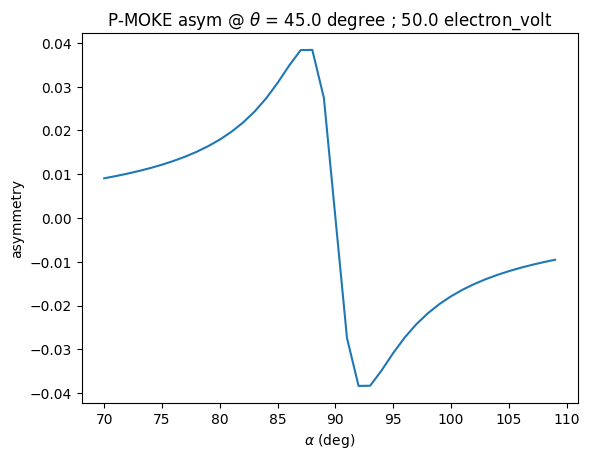

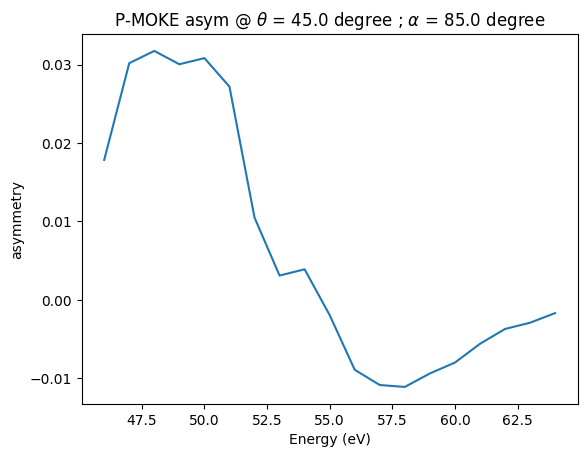

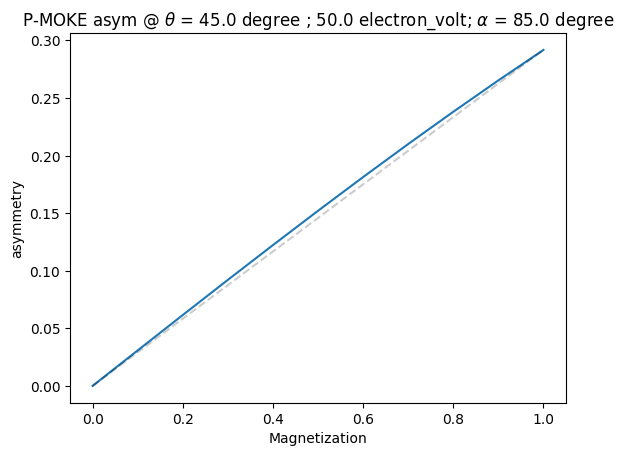

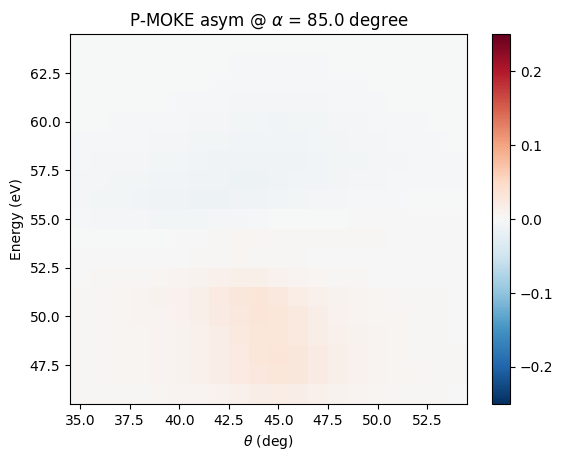

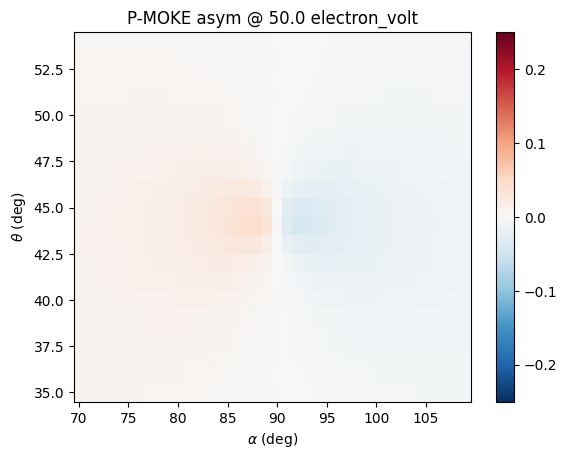

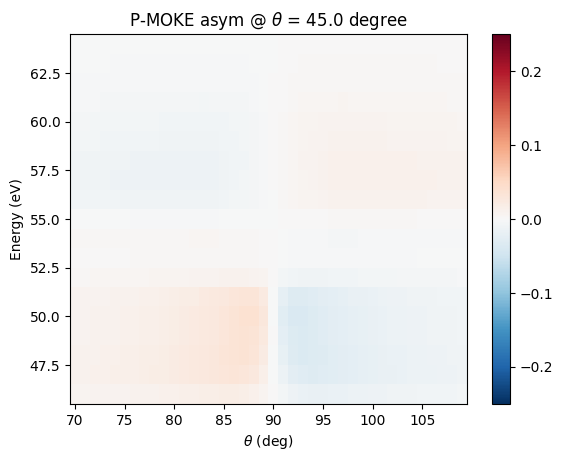

In [53]:
# fixed energy and angle
energy_index = 4
angle_index = 10
mag_index = 1
plt.figure()
plt.plot(alphas, asym[energy_index , angle_index, :, mag_index])
plt.xlabel(r'$\alpha$ (deg)')
plt.ylabel('asymmetry')
plt.title(r'P-MOKE asym @ $\theta$ = {:.1f} ; {:.1f}'.format(dyn_mag.theta[0, angle_index], dyn_mag.energy[energy_index]))
plt.show()

# fixed polarization and angle
angle_index = 10
pol_index = 15
plt.figure()
plt.plot(dyn_mag.energy, asym[: , angle_index, pol_index, mag_index])
plt.xlabel(r'Energy (eV)')
plt.ylabel('asymmetry')
plt.title(r'P-MOKE asym @ $\theta$ = {:.1f} ; $\alpha$ = {:.1f}'.format(dyn_mag.theta[0, angle_index], alphas[pol_index]))
plt.show()

energy_index = 4
angle_index = 10
pol_index = 15
plt.figure()
plt.plot(magnetizations, asym[energy_index , angle_index, pol_index, :])

plt.plot([magnetizations[0], magnetizations[-1]], [asym[energy_index , angle_index, pol_index, 0], asym[energy_index , angle_index, pol_index, -1]], '--k', alpha=0.2)

plt.xlabel(r'Magnetization')
plt.ylabel('asymmetry')
plt.title(r'P-MOKE asym @ $\theta$ = {:.1f} ; {:.1f}; $\alpha$ = {:.1f}'.format(dyn_mag.theta[0, angle_index], dyn_mag.energy[energy_index], alphas[pol_index]))
plt.show()

# fixed polarization
pol_index = 15
plt.figure()
plt.pcolormesh(dyn_mag.theta, dyn_mag.energy,
               asym[:, :, pol_index, mag_index],
               shading='auto', vmin=-.25, vmax=.25, cmap='RdBu_r')
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel('Energy (eV)')
plt.colorbar()
plt.title(r'P-MOKE asym @ $\alpha$ = {:.1f}'.format(alphas[pol_index]))
plt.show()

# fixed energy
energy_index = 4
plt.figure()
plt.pcolormesh(alphas, dyn_mag.theta[0, :],
               asym[energy_index, :, :, mag_index],
               shading='auto', vmin=-.25, vmax=.25, cmap='RdBu_r')
plt.xlabel(r'$\alpha$ (deg)')
plt.ylabel(r'$\theta$ (deg)')
plt.colorbar()
plt.title(r'P-MOKE asym @ {:.1f}'.format(dyn_mag.energy[energy_index]))
plt.show()

# fixed angle
angle_index = 10
plt.figure()
plt.pcolormesh(alphas, dyn_mag.energy,
               asym[:, angle_index, :, mag_index],
               shading='auto', vmin=-.25, vmax=.25, cmap='RdBu_r')
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel('Energy (eV)')
plt.colorbar()
plt.title(r'P-MOKE asym @ $\theta$ = {:.1f}'.format(dyn_mag.theta[0, angle_index]))
plt.show()

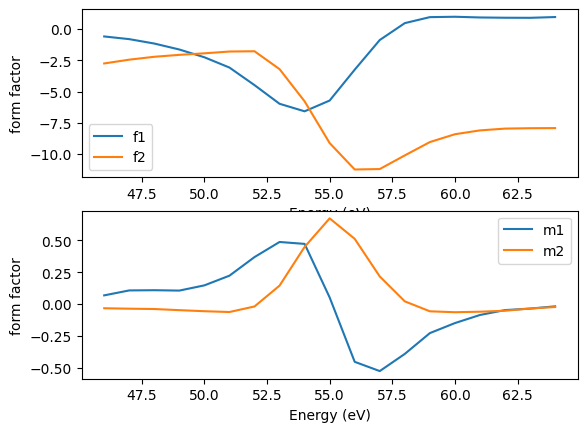

In [54]:
plt.figure()

plt.subplot(2,1,1)

plt.plot(dyn_mag.energy, np.real(Fe.get_atomic_form_factor(dyn_mag.energy)), label='f1')
plt.plot(dyn_mag.energy, np.imag(Fe.get_atomic_form_factor(dyn_mag.energy)), label='f2')

plt.legend()
plt.xlabel('Energy (eV)')
plt.ylabel('form factor')

plt.subplot(2,1,2)
plt.plot(dyn_mag.energy, np.real(Fe.get_magnetic_form_factor(dyn_mag.energy)), label='m1')
plt.plot(dyn_mag.energy, np.imag(Fe.get_magnetic_form_factor(dyn_mag.energy)), label='m2')

plt.legend()
plt.xlabel('Energy (eV)')
plt.ylabel('form factor')
plt.show()

# Test optical MOKE

In [32]:
Fe_optical = ud.Atom('Fe')
Si_optical = ud.Atom('Si')

Si_optical.get_atomic_form_factor(3*u.eV)

np.complex128(0.550431+0j)

In [33]:
Fe_optical.get_atomic_form_factor(3*u.eV)

layer_Fe.atom = Fe_optical
layer_Si.atom = Si_optical

In [34]:
dyn_mag.energy = np.r_[3.0]*u.eV
dyn_mag.theta = np.r_[0.1:90:0.01]*u.deg



/home/schick/Programming/git/udkm1Dsim/udkm1Dsim/simulations/xrays.py:247: RuntimeWarning: invalid value encountered in arcsin
  self._theta = np.arcsin(np.outer(self._wl, self._qz[0, :])/np.pi/4)


In [35]:
dyn_mag.set_polarization(3, 0)
R, _, T, _, = dyn_mag.homogeneous_reflectivity()

incoming polarizations set to: sigma
analyzer polarizations set to: unpolarized
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 2.946199 s


In [354]:
R

array([[nan, nan, nan, ..., nan, nan, nan]])

In [355]:
T

array([[nan, nan, nan, ..., nan, nan, nan]])

In [356]:
dyn_mag.S.get_layer_handle(1).atom.get_atomic_form_factor(3*u.eV)

(0.550431+0j)

incoming polarizations set to: sigma
analyzer polarizations set to: unpolarized
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 2.738516 s
incoming polarizations set to: pi
analyzer polarizations set to: unpolarized
Calculating _homogeneous_reflectivity_ ...
Elapsed time for _homogeneous_reflectivity_: 3.018383 s


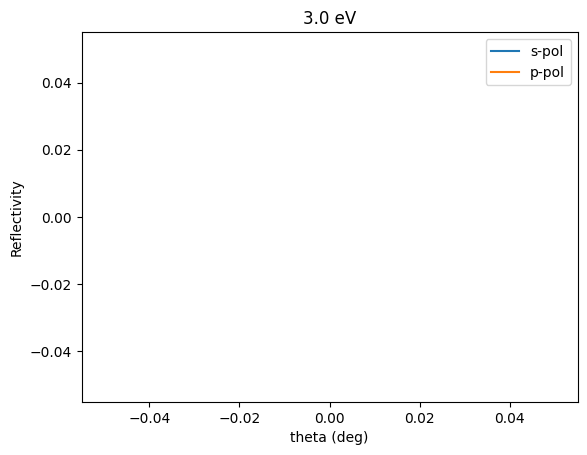

In [36]:
plt.figure()
dyn_mag.set_polarization(3, 0)
R, _, T, _, = dyn_mag.homogeneous_reflectivity()

plt.plot(dyn_mag.theta[0, :], R[0, :], label='s-pol')

dyn_mag.set_polarization(4, 0)
R, _, T, _, = dyn_mag.homogeneous_reflectivity()
plt.plot(dyn_mag.theta[0, :], R[0, :], label='p-pol')

plt.legend()
plt.title('3.0 eV')
plt.xlabel('theta (deg)')
plt.ylabel('Reflectivity')
plt.show()

In [332]:
dyn_mag.theta[0, :]

Magnitude,[0.1 0.11 0.12 ... 89.96999999999996 89.97999999999995 89.98999999999995]
Units,deg


In [281]:
dyn_mag.energy

Magnitude,[1.5]
Units,eV
